<a href="https://colab.research.google.com/github/henriqueprrpnunes/MVP_Analise_de_Dados_e_Boas_Praticas/blob/main/MVP_An%C3%A1lise_de_Dados_e_Boas_Pr%C3%A1ticas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP Análise de Dados e Boas Práticas

**Nome:** Henrique Nunes

**Dataset:** [Housing](https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download)



# Descrição do Problema

O projeto tem como objetivo prever o preço de imóveis residenciais com base em características estruturais e de localização das casas. A ideia é construir um modelo de aprendizado de máquina capaz de estimar o valor de mercado de uma casa a partir de variáveis observáveis, como: Área do imóvel (ft²), número de quartos, número de banheiros, número de andares, acesso direto a uma via principal, presença de quarto de hóspedes, presença de porão, presença de sistema de aquecimento de água, presença de ar-condicionado, número de vagas de estacionamento, se o imóvel está em uma área considerada valorizada e condição de mobília do imóvel (mobiliado, semi-mobiliado ou não mobiliado).

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Existe uma relação forte entre o tamanho do imóvel e o preço?**

2. **Casas localizadas em áreas preferenciais possuem preços mais altos?**

3. **Características estruturais e de conforto ajudam a explicar o preço das casas?**

## Tipo de Problema

Este é um problema de aprendizado supervisionado, pois o modelo é treinado a partir de dados históricos que contêm Variáveis explicativas (características do imóvel) e Variável alvo (preço do imóvel).

Mais especificamente, trata-se de um problema de regressão, pois a variável que se deseja prever (preço da casa) é numérica e contínua.

Alguns modelos que podem ser utilizados incluem:

- Regressão Linear

- Random Forest Regressor

- Gradient Boosting (XGBoost, LightGBM)

- Redes neurais

O desempenho do modelo pode ser avaliado por métricas como:

- MAE (Erro absoluto médio)

- RMSE (Raiz do erro quadrático médio)

- R² (coeficiente de determinação)

## Seleção de Dados

O dataset Housing é um conjunto de dados amplamente disponibilizado no Kaggle. Tem uma nota de usabilidade perfeita, sendo uma base completa, compatível e com ótima credibilidade.

## Atributos do Dataset

O dataset Housing contém 545 amostras. Apresenta 13 atributos:

- price	(preço do imóvel)
- area (área do imóvel (ft²))
- bedrooms (número de quartos)
- bathrooms	(número de banheiros)
- stories	(número de andares da casa)
- mainroad	(se o imóvel tem acesso direto a uma via principal)
- guestroom	(presença de quarto de hóspedes)
- basement	(presença de porão)
- hotwaterheating	(presença de sistema de aquecimento de água)
- airconditioning	(presença de ar-condicionado)
- parking	(número de vagas de estacionamento)
- prefarea	(se o imóvel está em uma área considerada valorizada)
- furnishingstatus	(condição de mobília do imóvel (mobiliado, semi-mobiliado ou não mobiliado))

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias para a análise, visualização e pré-processamento dos dados, bem como o carregamento inicial do dataset Housing.

In [68]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [69]:
# caminho do arquivo
path = "https://raw.githubusercontent.com/henriqueprrpnunes/MVP_Analise_de_Dados_e_Boas_Praticas/main/Housing"

# guardar dataset em um dataframe
df = pd.read_csv(path, sep=';')

In [70]:
# primeiras linhas
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


# Análise de Dados

Nesta etapa de Análise de Dados Exploratória sobre o dataset Housing, busca-se entender a distribuição, as relações e as características das variáveis, o que é crucial para as etapas subsequentes de pré-processamento e modelagem.

## Total e Tipo das Instâncias

O conjunto de dados contém 545 registros de imóveis e 13 variáveis, incluindo características estruturais, de infraestrutura e de localização. As variáveis estão divididas entre 6 variáveis numéricas e 7 variáveis categóricas, e não há presença de valores ausentes.

In [71]:
print(f"Total de instâncias: {len(df)}")
print("\nTipos de dados por coluna:")
print(df.info())

Total de instâncias: 545

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None


## Variáveis numéricas

A análise das variáveis numéricas constitui a etapa inicial da exploração dos dados, com o objetivo de compreender a estrutura, distribuição e comportamento dos principais atributos quantitativos do conjunto de dados.

### Estatísticas Descritivas

Estatísticas descritivas fornecem um resumo das características numéricas, incluindo média, desvio padrão, mínimo, máximo e quartis.

In [72]:
# estatísticas descritivas básicas do dataset
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


A tabela de estatísticas descritivas acima já traz vários insights importantes sobre o comportamento dos preços dos imóveis e de algumas variáveis explicativas.

A variável alvo, preço (price), apresenta média de aproximadamente 4,77 milhões e mediana de 4,34 milhões, indicando assimetria à direita. Isso sugere a presença de imóveis de alto valor que elevam a média. O desvio padrão elevado (1,87 milhões) e a diferença significativa entre o terceiro quartil (5,74 milhões) e o valor máximo (13,3 milhões) reforçam a existência de outliers. Esse comportamento indica a necessidade de considerar transformações, como logaritmo, para estabilizar a variância e melhorar o desempenho de modelos preditivos.

A variável área (area) também apresenta assimetria à direita, com média de 5.150 e mediana de 4.600. O valor máximo (16.200) é muito superior ao terceiro quartil (6.360), evidenciando a presença de outliers. Além disso, o alto desvio padrão indica grande variabilidade no tamanho dos imóveis. Essa variável tende a ter forte relação com o preço e também é candidata à transformação logarítmica.

As variáveis estruturais do imóvel apresentam menor dispersão. O número de quartos (bedrooms) possui média próxima de 3 e baixa variabilidade, indicando concentração em imóveis de padrão intermediário. O número de banheiros (bathrooms) apresenta média de 1,29 e mediana igual a 1, sugerindo predominância de imóveis com apenas um banheiro e leve assimetria à direita. A variável número de andares (stories) possui média de 1,8 e mediana de 2, indicando predominância de imóveis térreos ou com dois pavimentos.

A variável vagas de estacionamento (parking) apresenta média de 0,69 e mediana igual a 0, indicando que a maioria dos imóveis não possui vaga. A distribuição é assimétrica, com poucos imóveis possuindo múltiplas vagas.

De forma geral, observa-se que as variáveis preço e área possuem alta variabilidade e presença de outliers, enquanto as demais variáveis apresentam distribuições mais concentradas. Além disso, há diferenças significativas de escala entre as variáveis, o que pode impactar determinados modelos de machine learning.

Esses resultados indicam a necessidade de tratamento de assimetria, possível transformação de variáveis e análise adicional de correlação, especialmente entre área e preço.

### Histograma e Gráfico de Barras

A distribuição de dados descreve como os valores de uma variável se espalham, ou seja, a frequência com que diferentes valores ocorrem. Entender a distribuição é crucial na análise de dados, pois revela padrões, tendências centrais, dispersão e a presença de valores atípicos (outliers). Para variáveis contínuas, principalmente, o histograma é uma ferramenta visual fundamental para representar essa distribuição, mostrando a forma dos dados, se são simétricos ou assimétricos, unimodais ou multimodais. Enquanto isso, os gráficos de barras são mais eficientes para as variáveis discretas.

#### *Preço (price)*

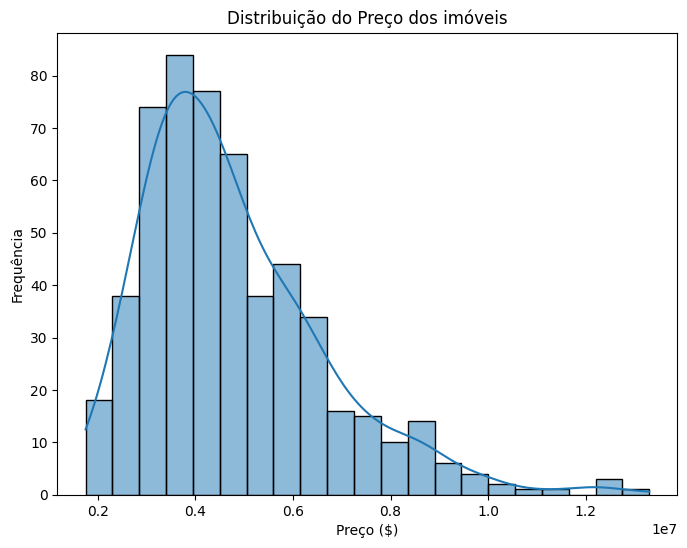

In [73]:
plt.figure(figsize=(8, 6))
# Histograma do preço
sns.histplot(df['price'], kde=True)
plt.title('Distribuição do Preço dos imóveis')
plt.xlabel('Preço ($)')
plt.ylabel('Frequência')
plt.show()

O histograma da variável price evidencia uma distribuição assimétrica à direita. A maior concentração de imóveis está na faixa entre aproximadamente 3 e 6 milhões, com pico em torno de 3,5 a 4,5 milhões, indicando que esse é o padrão predominante do mercado na base analisada.

Observa-se uma cauda longa à direita, com poucos imóveis atingindo valores significativamente mais altos, chegando a mais de 12 milhões. Isso confirma a presença de outliers, que elevam a média e aumentam a variabilidade da variável.

A distribuição não segue um formato normal, sendo claramente enviesada. Esse comportamento sugere a necessidade de transformação, como o uso de logaritmo na variável price, para reduzir a assimetria, estabilizar a variância e melhorar o desempenho de modelos preditivos, especialmente os baseados em regressão.

#### *Área (area)*

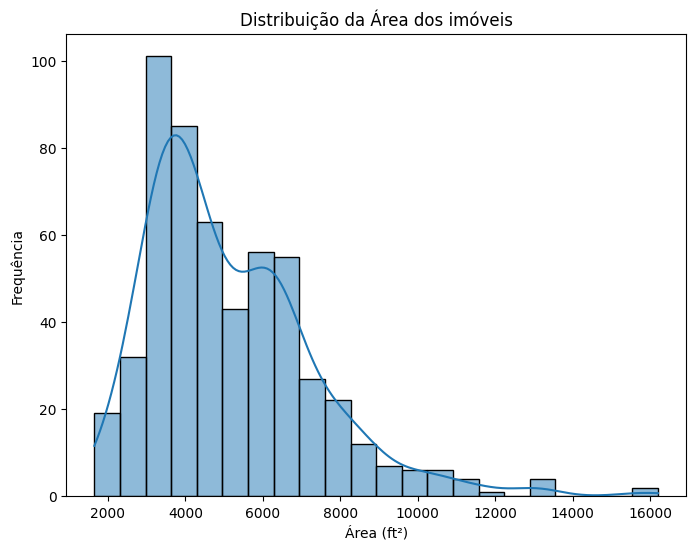

In [74]:
plt.figure(figsize=(8, 6))
# Histograma da área
sns.histplot(df['area'], kde=True)
plt.title('Distribuição da Área dos imóveis')
plt.xlabel('Área (ft²)')
plt.ylabel('Frequência')
plt.show()

O histograma da variável area mostra uma distribuição assimétrica à direita, com maior concentração de imóveis entre aproximadamente 3.000 e 6.000 ft². O pico da distribuição ocorre nessa faixa, indicando que esse é o padrão mais comum de tamanho dos imóveis na base.

Observa-se uma cauda longa à direita, com poucos imóveis apresentando áreas muito superiores, chegando a valores acima de 15.000 ft². Isso evidencia a presença de outliers e alta variabilidade na variável.

A distribuição não é normal e apresenta enviesamento, comportamento semelhante ao observado na variável price. Esse padrão reforça a relação esperada entre área e preço e indica que a variável area também pode se beneficiar de transformação logarítmica, visando reduzir a assimetria e melhorar a estabilidade dos modelos preditivos.

#### *Quartos (bedrooms)*

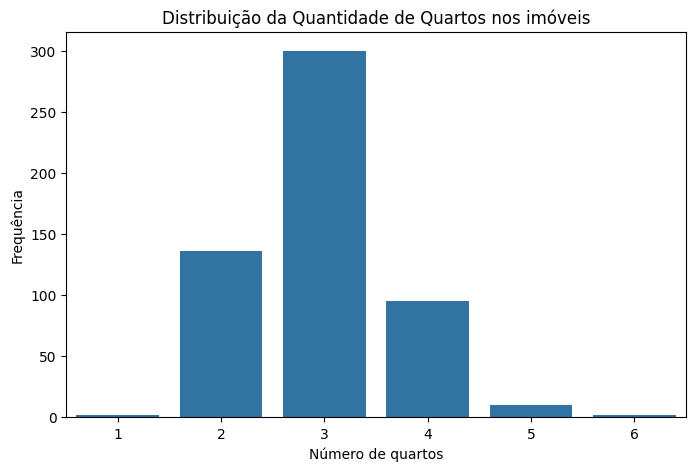

In [75]:
plt.figure(figsize=(8,5))
# Gráfico barras de quartos
sns.countplot(x='bedrooms', data=df, order=sorted(df['bedrooms'].unique()))
plt.title('Distribuição da Quantidade de Quartos nos imóveis')
plt.xlabel('Número de quartos')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da variável bedrooms evidencia forte concentração em imóveis com apenas 3 quartos, que representam a grande maioria da base. Do ponto de vista de dispersão, os dados apresentam uma forte concentração central, com a grande maioria da amostra situada no intervalo de 2 a 4 quartos.

As categorias 1, 5 e 6 quartos apresentam frequências marginais, caracterizando-se como classes sub-representadas de frequência na base de dados.

#### *Banheiros (bathrooms)*

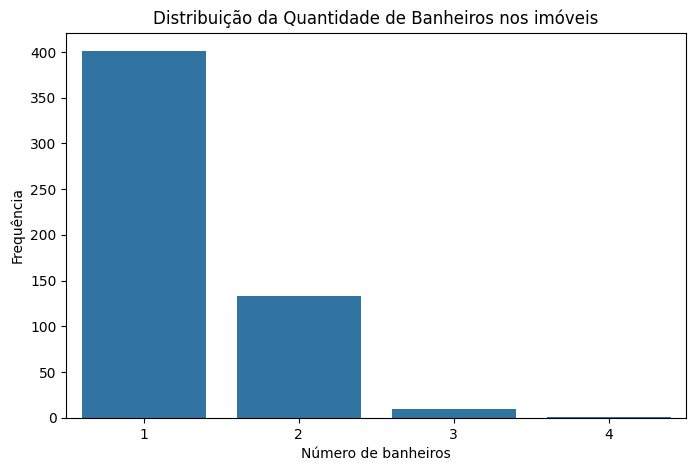

In [76]:
plt.figure(figsize=(8,5))
# Gráfico barras de banheiros
sns.countplot(x='bathrooms', data=df, order=sorted(df['bathrooms'].unique()))
plt.title('Distribuição da Quantidade de Banheiros nos imóveis')
plt.xlabel('Número de banheiros')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da variável bathrooms evidencia forte concentração em imóveis com apenas 1 banheiro, que representam a grande maioria da base. Em seguida, observa-se uma quantidade menor de imóveis com 2 banheiros, enquanto valores de 3 ou mais banheiros são raros.

Essa distribuição indica baixa variabilidade e uma assimetria à direita, com poucos imóveis de padrão mais elevado no que se refere à quantidade de banheiros. Esse comportamento sugere que a variável pode ter poder discriminatório principalmente na diferenciação entre imóveis básicos (1 banheiro) e intermediários (2 banheiros), mas com menor capacidade de capturar variações em imóveis de alto padrão devido à baixa frequência nesses níveis.

#### *Andares (stories)*

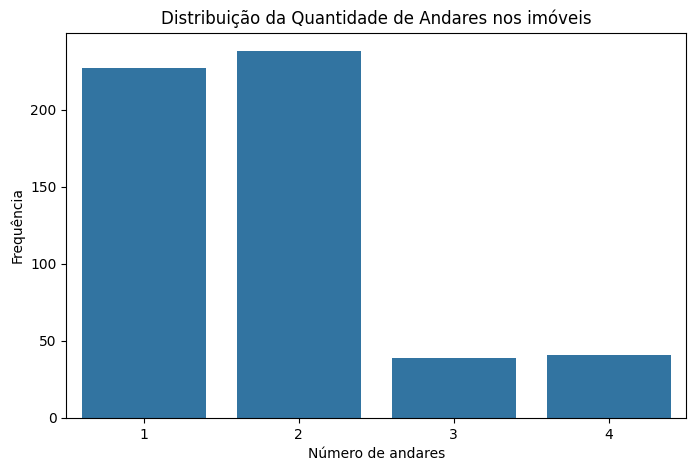

In [77]:
plt.figure(figsize=(8,5))
# Gráfico barras de andares
sns.countplot(x='stories', data=df, order=sorted(df['stories'].unique()))
plt.title('Distribuição da Quantidade de Andares nos imóveis')
plt.xlabel('Número de andares')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da variável stories revela uma distribuição com concentração predominante nos níveis inferiores, com a moda situada em 2 andares.

Observa-se uma forte representatividade de imóveis com 1 e 2 andares, que juntos compõem a vasta maioria da amostra, enquanto as categorias de 3 e 4 andares apresentam uma queda drástica na frequência.

#### *Estacionamentos (parking)*

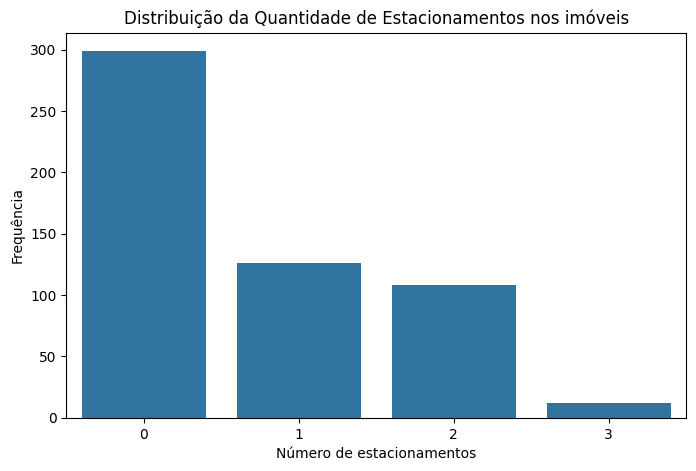

In [78]:
plt.figure(figsize=(8,5))
# Gráfico barras de estacionamentos
sns.countplot(x='parking', data=df, order=sorted(df['parking'].unique()))
plt.title('Distribuição da Quantidade de Estacionamentos nos imóveis')
plt.xlabel('Número de estacionamentos')
plt.ylabel('Frequência')

plt.show()

O gráfico de barras da váriavel parking apresenta uma concentração predominante de imóveis sem estacionamento, seguida por uma redução significativa na frequência para as categorias de 1 vaga e 2 vagas.

A categoria de 3 vagas apresenta-se como uma classe sub-representada, com uma frequência significativamente menor dentre todas as outras.

### Boxplot

Os gráficos de Boxplot para as variáveis contínuas do conjunto de dados tem como objetivo de avaliar a dispersão, a posição central e a presença de valores extremos (outliers). Essa abordagem permite uma visualização mais objetiva da variabilidade dos dados e da existência de observações atípicas. A identificação desses pontos é importante para orientar decisões de tratamento, como transformações ou remoção de outliers.

#### *Preço (price)*


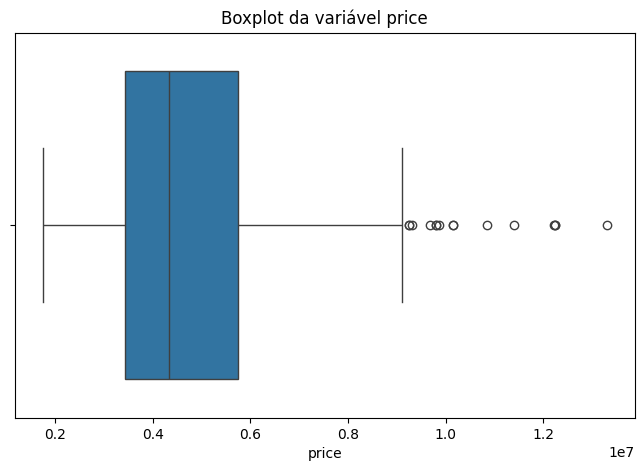

In [79]:
#Boxplot Preço

plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title('Boxplot da variável price')
plt.xlabel('price')

plt.show()

In [80]:
# Cálculo dos quartis
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Selecionando apenas os valores outliers
outliers = df.loc[
    (df['price'] < limite_inferior) | (df['price'] > limite_superior),
    'price'
]

# Exibindo valores de outliers
print(outliers.values)

[13300000 12250000 12250000 12215000 11410000 10850000 10150000 10150000
  9870000  9800000  9800000  9681000  9310000  9240000  9240000]


#### *Área (area)*

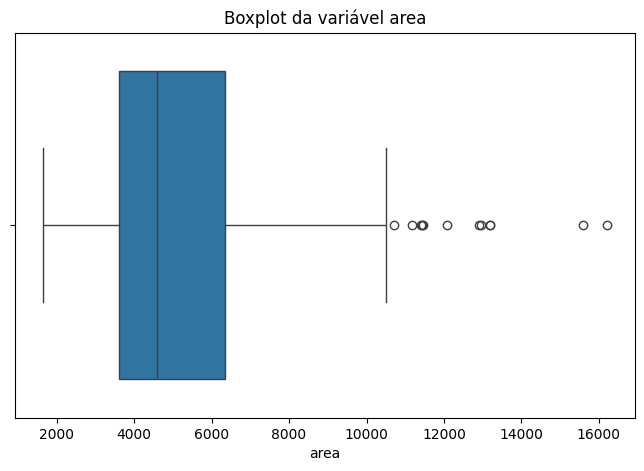

In [81]:
#Boxplot Área

plt.figure(figsize=(8,5))

sns.boxplot(x=df['area'])

plt.title('Boxplot da variável area')
plt.xlabel('area')

plt.show()

In [82]:
# Cálculo dos quartis
Q1 = df['area'].quantile(0.25)
Q3 = df['area'].quantile(0.75)
IQR = Q3 - Q1

# Limites
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Selecionando apenas os valores outliers
outliers = df.loc[
    (df['area'] < limite_inferior) | (df['area'] > limite_superior),
    'area'
]

# Exibindo valores de outliers
print(outliers.values)

[16200 13200 11440 11175 13200 12090 15600 11460 11410 10700 12900 12944]


A análise dos outliers identificados para as variáveis price e area confirma a presença de imóveis de padrão significativamente superior ao restante da base, o que já havia sido sugerido pelas estatísticas descritivas e histogramas.

No caso de price, os valores outliers variam aproximadamente entre 9,24 milhões e 13,3 milhões, situando-se muito acima da faixa onde se concentra a maior parte dos dados. A repetição de alguns valores indica que não se tratam de erros pontuais, mas sim de um subconjunto consistente de imóveis de alto padrão. Esses imóveis exercem forte influência sobre a média e aumentam a variabilidade da variável, podendo impactar modelos sensíveis a extremos, como regressões lineares.

Para a variável area, os outliers variam entre aproximadamente 10.700 e 16.200, também muito acima do padrão central da distribuição. Assim como no preço, esses valores indicam a existência de imóveis significativamente maiores, o que reforça a relação estrutural entre área e preço. A presença desses pontos sugere um segmento de mercado distinto dentro da base.

De forma geral, os outliers identificados não aparentam ser erros, mas sim observações válidas que representam imóveis de alto padrão. Isso implica que sua remoção deve ser avaliada com cautela, pois pode resultar em perda de informação relevante. Alternativamente, o uso de transformações (como logaritmo) ou modelos mais robustos pode ser mais adequado para lidar com esses valores extremos sem descartá-los.

### Matriz de Correlação

A matriz de correlação mede a força e a direção de uma relação linear que os atributos numéricos podem ter. Valores próximos a 1 indicam uma forte correlação positiva, -1 uma forte correlação negativa, e 0 ausência de correlação linear.

In [83]:
# Selecionando apenas variáveis numéricas
df_numerico = df.select_dtypes(include=['int64', 'float64'])

# Matriz de correlação
correlacao = df_numerico.corr()

print(correlacao)

              price      area  bedrooms  bathrooms   stories   parking
price      1.000000  0.535997  0.366494   0.517545  0.420712  0.384394
area       0.535997  1.000000  0.151858   0.193820  0.083996  0.352980
bedrooms   0.366494  0.151858  1.000000   0.373930  0.408564  0.139270
bathrooms  0.517545  0.193820  0.373930   1.000000  0.326165  0.177496
stories    0.420712  0.083996  0.408564   0.326165  1.000000  0.045547
parking    0.384394  0.352980  0.139270   0.177496  0.045547  1.000000


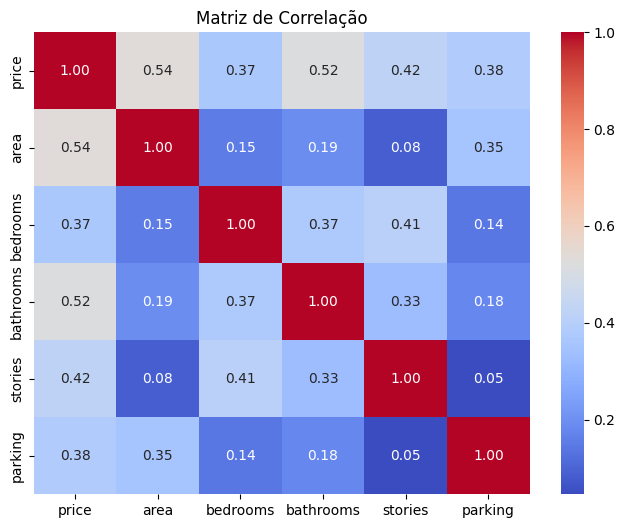

In [84]:
plt.figure(figsize=(8,6))

sns.heatmap(correlacao, annot=True, fmt=".2f", cmap="coolwarm")

plt.title('Matriz de Correlação')
plt.show()

A matriz de correlação indica que todas as variáveis analisadas possuem uma correlação positiva com o preço, sendo a área (0.54) e o número de banheiros (0.52) os fatores com maior influência direta no valor do imóvel.
O número de andares (0.42), vagas de garagem (0.38) e quartos (0.37) apresentam correlações moderadas, sugerindo que também são preditores relevantes para o modelo.
Entre as variáveis independentes, observa-se uma relação moderada entre quartos e andares (0.41) e entre quartos e banheiros (0.37), mas a ausência de coeficientes extremamente elevados (acima de 0.80) sugere que não há problemas críticos de multicolinearidade, o que favorece a estabilidade de algoritmos de regressão para a projeção de preços.

### Gráficos de dispersão

Os gráficos de dispersão são utilizados com o objetivo de investigar a relação entre a variável alvo (price) e as demais variáveis explicativas. Essa abordagem permite visualizar padrões de associação, identificar possíveis relações lineares ou não lineares, além de evidenciar a presença de outliers e a dispersão dos dados.

Os gráficos de dispersão complementam a análise de correlação, possibilitando uma interpretação mais aprofundada das relações entre as variáveis, uma vez que a correlação linear, por si só, não captura totalmente a complexidade dos dados. Dessa forma, essa etapa contribui para validar os principais fatores associados ao preço dos imóveis e apoiar decisões mais fundamentadas na etapa de modelagem.

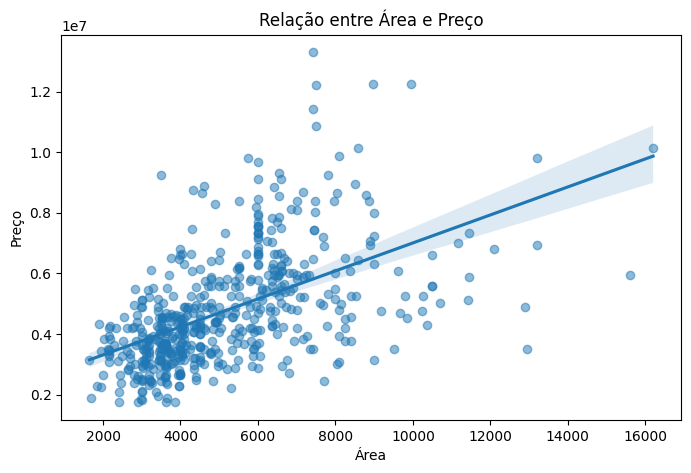

In [85]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x area
sns.regplot(x=df['area'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Área e Preço')
plt.xlabel('Área')
plt.ylabel('Preço')

plt.show()

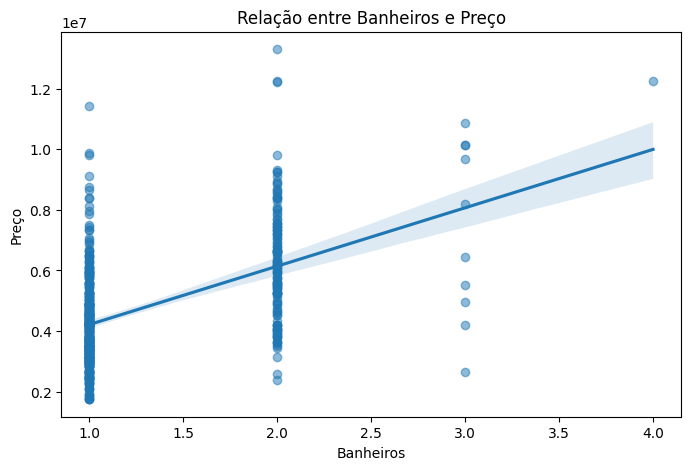

In [86]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x banheiros
sns.regplot(x=df['bathrooms'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Banheiros e Preço')
plt.xlabel('Banheiros')
plt.ylabel('Preço')

plt.show()

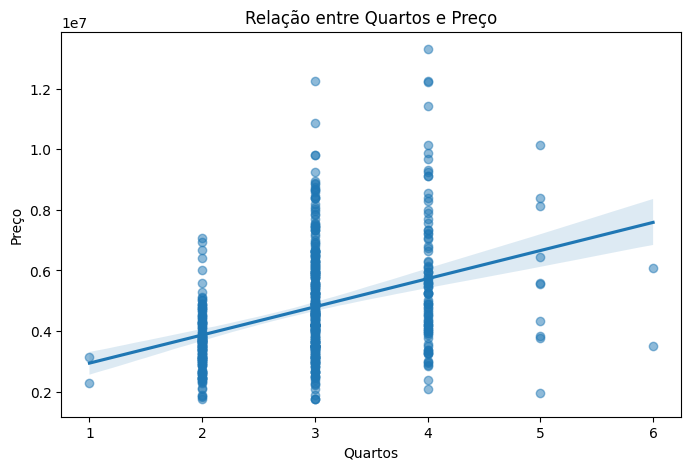

In [87]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x quartos
sns.regplot(x=df['bedrooms'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Quartos e Preço')
plt.xlabel('Quartos')
plt.ylabel('Preço')

plt.show()

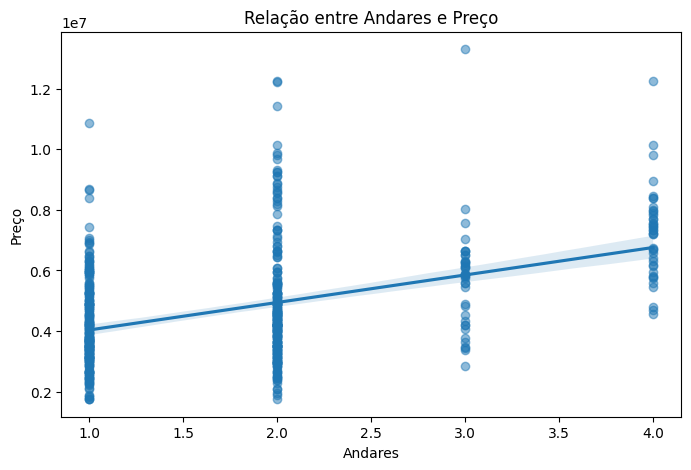

In [88]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x andares
sns.regplot(x=df['stories'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Andares e Preço')
plt.xlabel('Andares')
plt.ylabel('Preço')

plt.show()

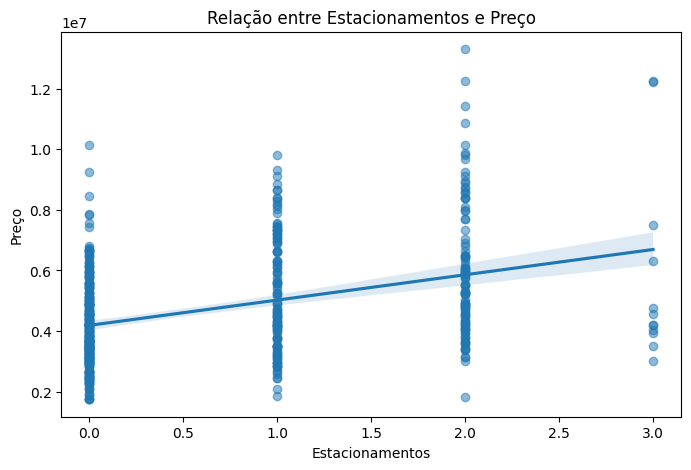

In [89]:
plt.figure(figsize=(8,5))
# Gráfico dispersão preço x estacionamentos
sns.regplot(x=df['parking'], y=df['price'], scatter_kws={'alpha':0.5})
plt.title('Relação entre Estacionamentos e Preço')
plt.xlabel('Estacionamentos')
plt.ylabel('Preço')

plt.show()

A análise integrada da matriz de correlação e dos gráficos de dispersão revela que, embora exista uma tendência linear positiva entre as características físicas e o preço, essa relação é complexa e marcada por uma elevada variabilidade interna.

De um lado, o heatmap confirma que a área (0.54) e o número de banheiros (0.52) são os principais vetores de valor, apresentando os coeficientes de correlação mais robustos da base de dados.

Visualmente, isso se traduz em linhas de regressão claramente ascendentes em todos os gráficos de dispersão, validando estatisticamente que o incremento em atributos como quartos, vagas e andares geralmente impulsiona o valor de mercado da propriedade.

Por outro lado, a observação detalhada dos gráficos de dispersão expõe a imperfeição dessa linearidade, especialmente nas variáveis discretas, que se manifestam como "colunas verticais" de dados.

Nestas variáveis, nota-se uma sobreposição massiva de preços entre diferentes categorias: é comum encontrar imóveis com apenas 2 quartos que superam em preço unidades com 3 ou 4 quartos, ou casas sem vagas de garagem custando mais do que aquelas com duas vagas.

Essa dispersão acentuada dentro de cada nível (como a amplitude observada em imóveis de 2 andares) demonstra que o preço é multifatorial.

O valor final não é determinado por um único atributo isolado, mas pela interação entre eles; uma área total maior ou uma localização privilegiada podem facilmente compensar a falta de um quarto adicional.

Essa dualidade explica por que as correlações com o preço, apesar de positivas, situam-se em patamares moderados (entre 0.37 e 0.54) e não próximos da perfeição.

A presença de outliers de alto valor no topo de todos os gráficos reforça que o segmento de luxo se descola da tendência média da massa de dados, apresentando comportamentos que desafiam a média linear.

Para o projeto de ciência de dados, esses resultados indicam que modelos preditivos simples podem sofrer com a alta variância dos dados, tornando essencial o uso de algoritmos capazes de captar essas nuances e interdependências para gerar projeções de preço mais precisas e menos enviesadas pela dispersão natural do mercado.

## Variáveis categóricas

A análise das variáveis categóricas tem como objetivo complementar a compreensão do comportamento do preço dos imóveis, incorporando atributos qualitativos que não são capturados pelas variáveis numéricas.

### Boxplot

 Busca comparar visualmente a distribuição dos preços entre as diferentes categorias, evidenciando diferenças de mediana, dispersão e presença de outliers.

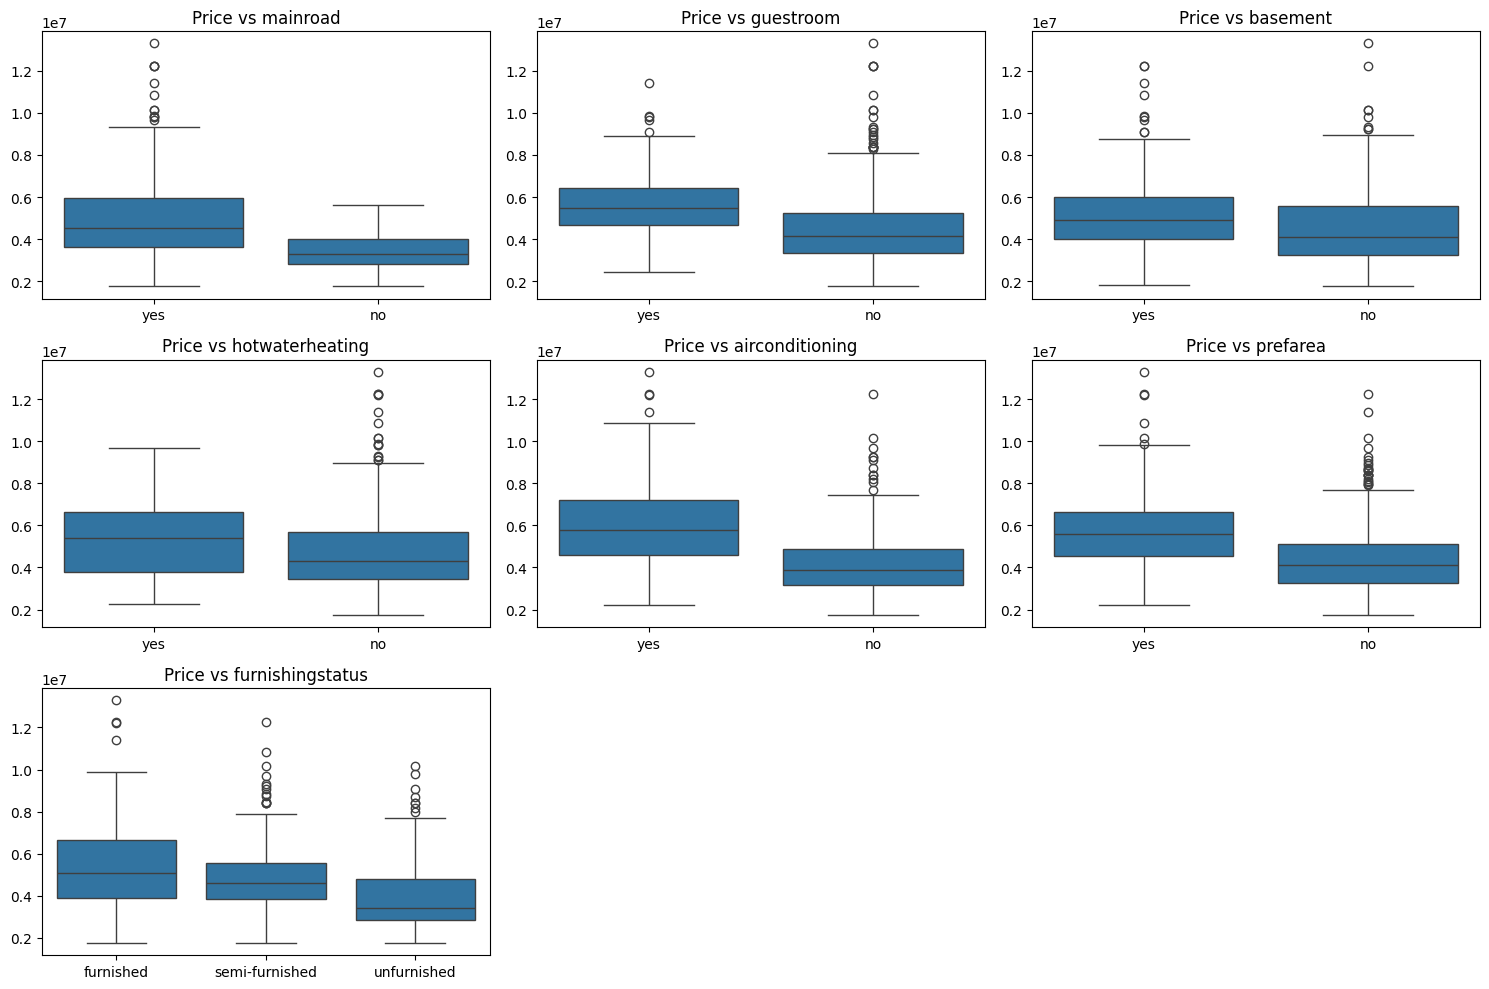

In [90]:
# lista das variáveis categóricas
categorical_vars = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

n_cols = 3
n_rows = (len(categorical_vars) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 10))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(n_rows, n_cols, i)

    # aplica ordem apenas para variáveis binárias
    if df[var].nunique() == 2:
        sns.boxplot(x=var, y='price', data=df, order=['yes', 'no'])
    else:
        sns.boxplot(x=var, y='price', data=df)

    plt.title(f'Price vs {var}')
    plt.xlabel('')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### Mediana de preço por grupo

Fornece uma medida objetiva dessas diferenças, reforçando os padrões observados graficamente.

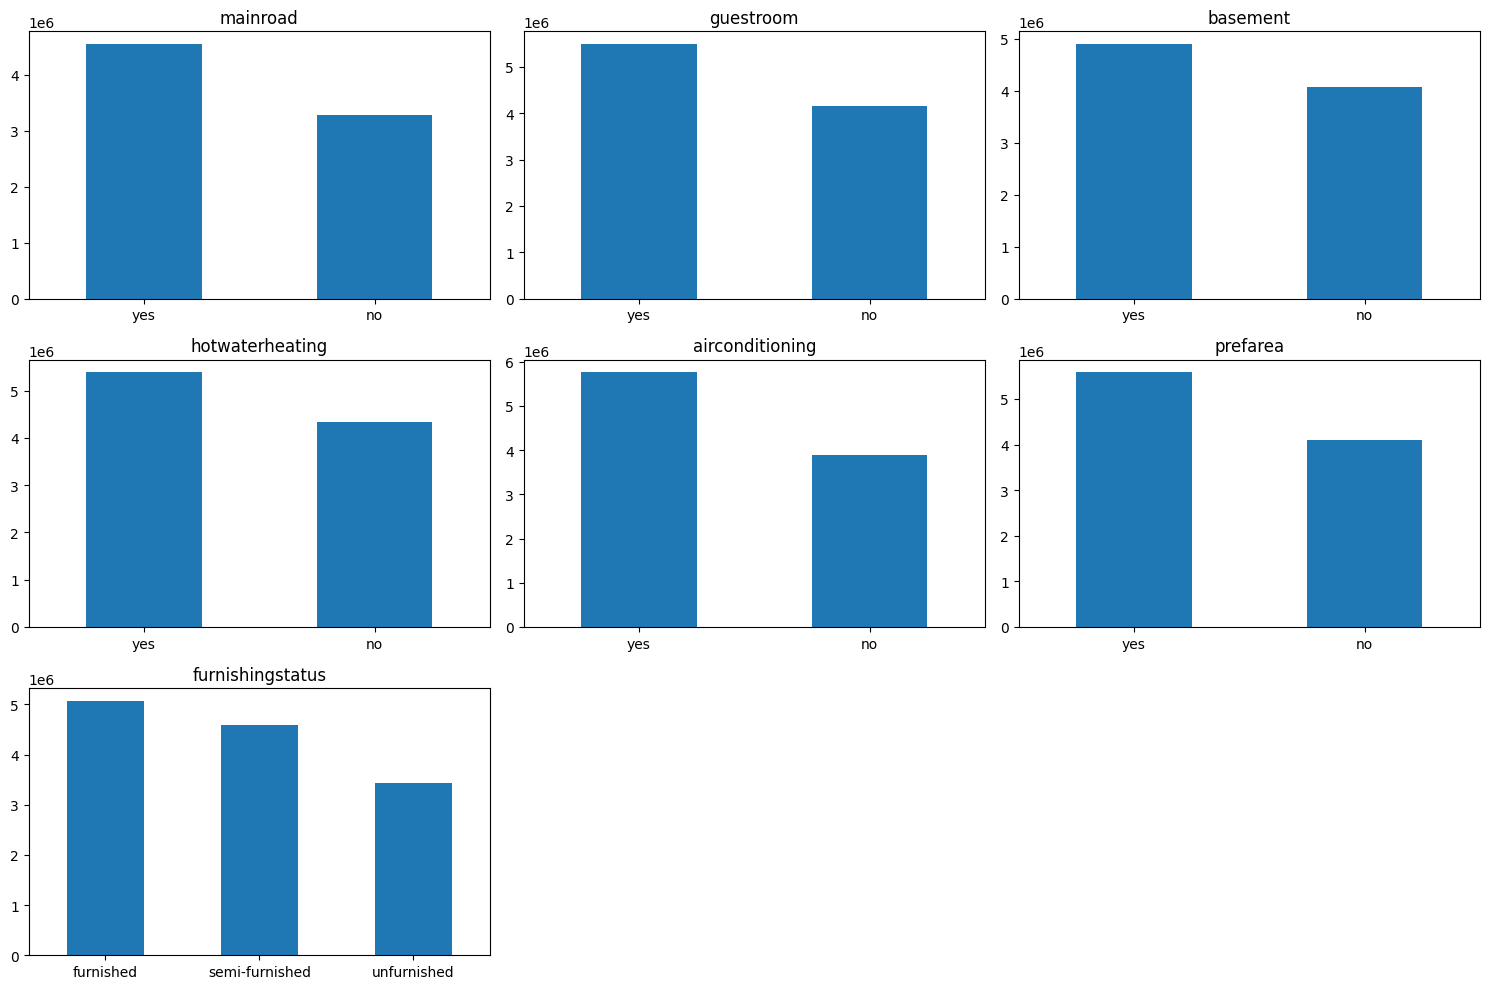

In [91]:
# lista das variáveis categóricas
categorical_vars = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea',
    'furnishingstatus'
]

# layout da grade
n_cols = 3
n_rows = (len(categorical_vars) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 10))

for i, var in enumerate(categorical_vars, 1):
    plt.subplot(n_rows, n_cols, i)

    medians = df.groupby(var)['price'].median().sort_values(ascending=False)
    medians.plot(kind='bar')

    plt.title(var)
    plt.xlabel('')
    plt.ylabel('')
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

A análise conjunta dos boxplots e dos gráficos de mediana por grupo permite uma avaliação mais robusta e consistente do impacto das variáveis categóricas sobre o preço dos imóveis, combinando evidência visual (distribuição) com medidas estatísticas (mediana).

Entre todas as variáveis, airconditioning e prefarea se destacam como os fatores de maior impacto. Nos boxplots, essas variáveis apresentam uma separação mais clara entre as categorias “yes” e “no”, com menor sobreposição relativa e maior deslocamento da mediana. Essa evidência é confirmada nos gráficos de barras, onde essas categorias apresentam as maiores medianas de preço entre todas as variáveis analisadas. Isso indica que tanto a presença de ar-condicionado quanto a localização em áreas valorizadas são determinantes relevantes na precificação dos imóveis.

As variáveis guestroom e basement também apresentam impacto positivo, com medianas mais elevadas nas categorias “yes”. No entanto, os boxplots mostram uma sobreposição considerável entre os grupos, indicando que, embora contribuam para a valorização, seu efeito é mais moderado e dependente de outros fatores. Os gráficos de mediana reforçam essa interpretação ao mostrar diferenças consistentes, porém menos acentuadas.

No caso de mainroad, observa-se um impacto intermediário. A mediana de imóveis com acesso à via principal é superior, mas a dispersão e a sobreposição indicam que esse atributo, isoladamente, não é suficiente para explicar grandes variações de preço.

A variável hotwaterheating apresenta um comportamento interessante: apesar de a mediana ser maior para imóveis com esse recurso, a diferença não é tão expressiva visualmente nos boxplots, sugerindo que seu impacto é relativamente limitado ou possivelmente influenciado por outros atributos correlacionados.

Já a variável furnishingstatus apresenta um padrão bem definido e consistente: imóveis mobiliados possuem maior mediana de preço, seguidos pelos semi-mobiliados e, por fim, os não mobiliados. Esse comportamento aparece de forma clara tanto nos boxplots quanto nos gráficos de barras, indicando uma relação ordinal bem estruturada. Ainda assim, a presença de sobreposição entre os grupos reforça que esse fator não atua de forma isolada.

Outro ponto importante é a presença de outliers em todas as variáveis, especialmente na faixa superior de preços. Esses valores extremos, já identificados anteriormente, continuam aparecendo independentemente da categoria analisada, indicando que imóveis de alto padrão estão distribuídos em diferentes perfis e não concentrados em uma única característica específica.

Por fim, a análise conjunta reforça a principal conclusão do projeto até aqui: o preço dos imóveis é resultado de um processo multifatorial. Embora variáveis categóricas como localização (prefarea) e infraestrutura (airconditioning) tenham impacto significativo, nenhuma variável isolada é capaz de explicar completamente a variabilidade dos preços. A combinação entre atributos qualitativos e quantitativos é essencial, o que justifica a necessidade de modelos preditivos mais robustos, capazes de capturar essas interações e não linearidades.

## Tratamento de Valores Nulos

O dataset Housing não possui valores nulos. No entanto, o tratamento de valores nulos é crucial e pode envolver imputação (preenchimento com média, mediana, moda) ou remoção de linhas/colunas.

In [92]:
# Verificar a presença de valores nulos no dataset original
print("Valores nulos no dataset Housing:")
df.isnull().sum()

Valores nulos no dataset Housing:


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


# Pré-Processamento de Dados

O pré-processamento de dados é uma etapa crucial para preparar os dados para modelagem, garantindo que estejam no formato correto e otimizados para o desempenho do algoritmo.

In [93]:
# Cópia do dataset
df_model = df.copy()

## Transformação Logarítmica

A transformação logarítmica foi aplicada às variáveis price e area com o objetivo de reduzir a assimetria à direita identificada na análise exploratória. Essa técnica contribui para a estabilização da variância, diminui o impacto de outliers e melhora a adequação dos dados a modelos preditivos, especialmente aqueles que assumem relações mais próximas da linearidade.

In [94]:
# Transformações logarítimicas
df_model['price'] = np.log(df_model['price'])
df_model['area'] = np.log(df_model['area'])

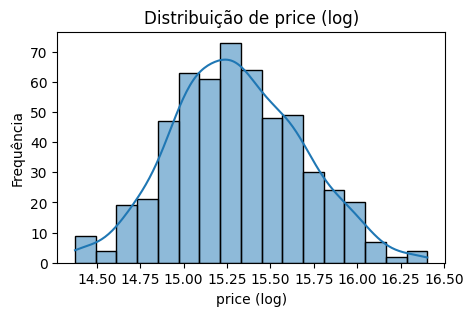

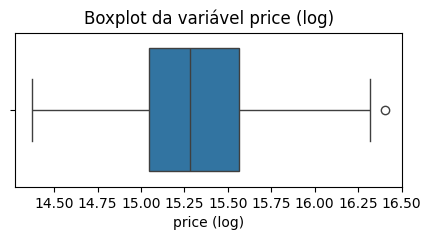

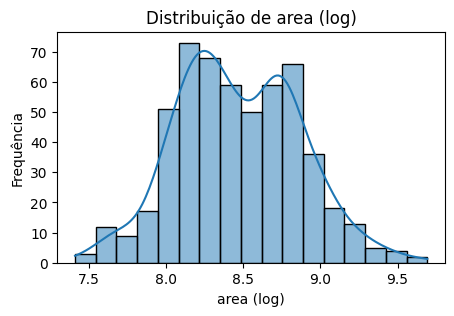

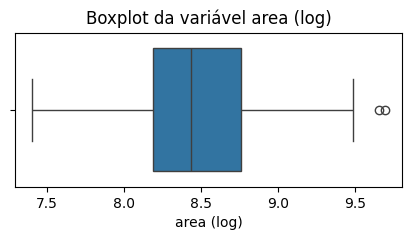

In [95]:
variaveis = ['price', 'area']

for var in variaveis:

    # Histograma
    plt.figure(figsize=(5, 3))
    sns.histplot(df_model[var], kde=True)
    plt.title(f'Distribuição de {var} (log)')
    plt.xlabel(f'{var} (log)')
    plt.ylabel('Frequência')
    plt.show()

    # Boxplot
    plt.figure(figsize=(5,2))
    sns.boxplot(x=df_model[var])
    plt.title(f'Boxplot da variável {var} (log)')
    plt.xlabel(f'{var} (log)')
    plt.show()

Com essa transformação, as distribuições tornaram-se visivelmente mais simétricas e próximas da normalidade, apresentando um comportamento muito mais equilibrado nos histogramas
. Essa mudança é nitidamente confirmada pelos novos boxplots, onde a escala comprimida conseguiu "puxar" os valores extremos para mais perto da mediana, reduzindo drasticamente a incidência de pontos fora da curva e centralizando a massa de dados
. Para o sucesso do modelo de projeção de preços, esse tratamento é um passo crítico, pois mitiga o viés causado por propriedades excepcionalmente grandes ou caras e prepara as variáveis para que o algoritmo de regressão trabalhe com relações mais lineares e uma variância mais estável.

## Codificação de Variáveis Categóricas (Encoding)

As variáveis categóricas foram convertidas para formato numérico a fim de viabilizar sua utilização em modelos de machine learning. As variáveis binárias foram transformadas em valores 0 e 1, enquanto a variável furnishingstatus foi codificada de forma ordinal, respeitando a hierarquia entre suas categorias. Esse processo garante que as informações qualitativas sejam incorporadas de forma adequada ao modelo.

In [96]:
# Encoding variáveis categóricas binárias
binary_cols = [
    'mainroad', 'guestroom', 'basement',
    'hotwaterheating', 'airconditioning', 'prefarea'
]

for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

In [97]:
# Encoding variável categórica ordinal
df_model['furnishingstatus'] = df_model['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

In [98]:
# primeiras linhas
df_model.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,16.403275,8.911934,4,2,3,1,0,0,0,1,2,1,2
1,16.321036,9.100526,4,4,4,1,0,0,0,1,3,0,2
2,16.321036,9.206332,3,2,2,1,0,1,0,0,2,1,1
3,16.318175,8.922658,4,2,2,1,0,1,0,1,3,1,2
4,16.250001,8.911934,4,1,2,1,1,1,0,1,2,0,2


## Separação entre Variáveis Independentes e Dependente (X e Y)

O conjunto de dados foi dividido entre variáveis explicativas (X) e variável alvo (Y), sendo esta representada pelo preço dos imóveis (price). Essa separação é fundamental para estruturar o problema de aprendizado supervisionado, permitindo que o modelo aprenda a relação entre os atributos dos imóveis e seu respectivo valor de mercado.

In [99]:
# Separar X e Y
X = df_model.drop('price', axis=1)
y = df_model['price']

## Divisão em Treino e Teste (Train-Test Split)

Os dados foram divididos em conjuntos de treino e teste, com o objetivo de avaliar o desempenho do modelo em dados não vistos. O conjunto de treino é utilizado para o ajuste do modelo, enquanto o conjunto de teste permite medir sua capacidade de generalização, evitando problemas como overfitting e garantindo maior confiabilidade nas previsões.

In [100]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Respondendo as hipóteses

## Hipótese 1: Existe uma relação forte entre o tamanho do imóvel e o preço?

Os resultados indicam que existe uma relação positiva e relevante entre o tamanho do imóvel (área) e o preço, sendo esta uma das associações mais consistentes da base de dados. A matriz de correlação evidenciou um coeficiente de aproximadamente 0.54, enquanto os gráficos de dispersão demonstraram uma tendência crescente clara entre as variáveis.

Entretanto, essa relação não é perfeitamente linear, apresentando alta variabilidade para um mesmo nível de área, o que indica que o tamanho, embora importante, não é o único fator determinante do preço. Assim, conclui-se que a área é um forte preditor, mas inserido em um contexto multifatorial.

## Hipótese 2: Casas localizadas em áreas preferenciais possuem preços mais altos?

A análise das variáveis categóricas, especialmente por meio de boxplots e comparação de medianas, mostra que imóveis localizados em áreas preferenciais (prefarea = yes) apresentam medianas de preço consistentemente superiores em relação aos demais.

Além disso, a distribuição dos preços nesses grupos indica uma concentração em faixas mais elevadas, reforçando que a localização exerce influência significativa na valorização dos imóveis.

Portanto, essa hipótese é confirmada, evidenciando que a localização é um dos fatores mais relevantes na formação do preço.

## Hipótese 3: Características estruturais e de conforto ajudam a explicar o preço das casas?

As análises indicam que variáveis relacionadas ao conforto e à estrutura do imóvel — como presença de ar-condicionado (airconditioning), quarto de hóspedes (guestroom), porão (basement) e número de banheiros — apresentam impacto positivo sobre o preço.

Isso foi observado tanto nas correlações (para variáveis numéricas) quanto nas diferenças de medianas entre grupos (para variáveis categóricas), onde imóveis com essas características tendem a apresentar valores mais elevados.

No entanto, assim como observado anteriormente, há uma sobreposição significativa entre os grupos, indicando que essas características não atuam de forma isolada, mas sim em conjunto com outros fatores, como área e localização.

Dessa forma, conclui-se que essas variáveis são preditores relevantes, contribuindo para explicar o preço, ainda que dentro de uma dinâmica multifatorial.

# Conclusão

De forma integrada, os resultados mostram que o preço dos imóveis é influenciado por um conjunto de fatores interdependentes, com destaque para área, localização e características estruturais. Nenhuma variável isoladamente explica o comportamento do preço, o que reforça a necessidade de modelos preditivos capazes de capturar relações não lineares e interações entre variáveis, como o Random Forest.